<a href="https://colab.research.google.com/github/Omkar7376/ml_codes/blob/master/EmployeeSalary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [ ]:
emp = pd.read_csv("/content/Employee_Salary_Dataset.csv")
emp.head()

,ID,Experience_Years,Age,Gender,Salary
0,1,5,28,Female,250000
1,2,1,21,Male,50000
2,3,3,23,Female,170000
3,4,2,22,Male,25000
4,5,1,17,Male,10000


In [ ]:
emp.tail()

,ID,Experience_Years,Age,Gender,Salary
30,31,10,34,Male,80000
31,32,15,54,Male,900000
32,33,20,55,Female,1540000
33,34,19,53,Female,9300000
34,35,16,49,Male,7600000


In [ ]:
emp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ID                35 non-null     int64 
 1   Experience_Years  35 non-null     int64 
 2   Age               35 non-null     int64 
 3   Gender            35 non-null     object
 4   Salary            35 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 1.5+ KB


In [ ]:
print(emp['Salary'].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

0.01       4020.0
0.05       6070.0
0.25      22500.0
0.50     250000.0
0.75    3270000.0
0.95    8320000.0
0.99    9762000.0
Name: Salary, dtype: float64


In [ ]:
emp[["Experience_Years", "Salary"]].describe()

,Experience_Years,Salary
count,35.00000,3.500000e+01
mean,9.20000,2.059147e+06
std,7.55295,3.170124e+06
min,1.00000,3.000000e+03
25%,2.50000,2.250000e+04
50%,6.00000,2.500000e+05
75%,15.00000,3.270000e+06
max,27.00000,1.000000e+07


In [ ]:
emp.isnull().sum()

,0
ID,0
Experience_Years,0
Age,0
Gender,0
Salary,0


In [ ]:
emp.duplicated().sum()

np.int64(0)

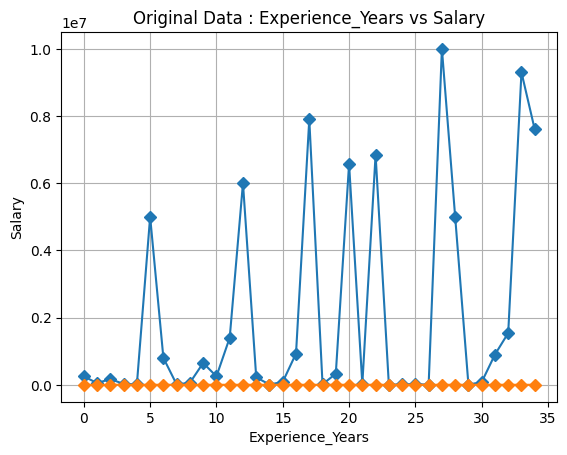

In [ ]:
plt.plot(emp[["Salary", "Experience_Years"]], marker = "D")
plt.xlabel("Experience_Years")
plt.ylabel("Salary")
plt.title("Original Data : Experience_Years vs Salary")
plt.grid()
plt.show()

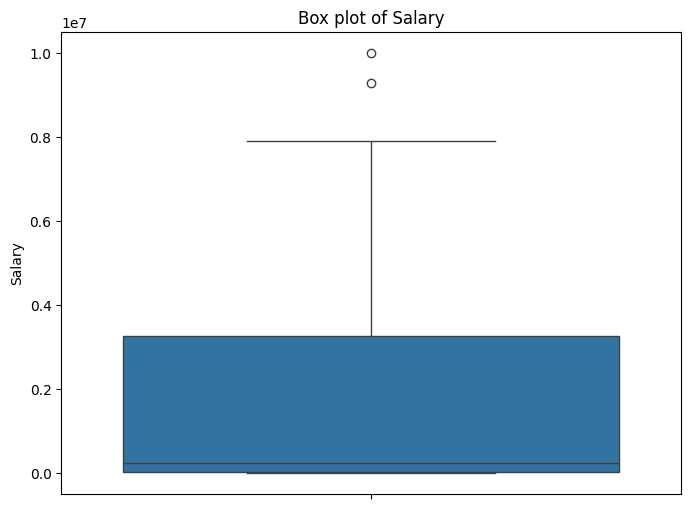

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=emp['Salary'])
plt.title('Box plot of Salary')
plt.ylabel('Salary')
plt.show()

In [ ]:
Q1 = emp["Salary"].quantile(0.25)
Q3 = emp["Salary"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower:", lower)
print("Upper:", upper)

Q1: 22500.0
Q3: 3270000.0
IQR: 3247500.0
Lower: -4848750.0
Upper: 8141250.0


In [ ]:
print("Outliers:")
print(emp[emp['Salary'] > upper]['Salary'].sort_values())

Outliers:
33     9300000
27    10000000
Name: Salary, dtype: int64


In [ ]:
outliers = emp[
    (emp['Salary'] < lower) |
    (emp['Salary'] > upper)
]

print(outliers[['Salary']])

      Salary
27  10000000
33   9300000


In [ ]:
# emp_clean = emp[
#     emp['Salary'].between(lower, upper)
# ].copy()

In [ ]:

# print("Original rows:", len(emp))
# print("After removing outliers:", len(emp_clean))

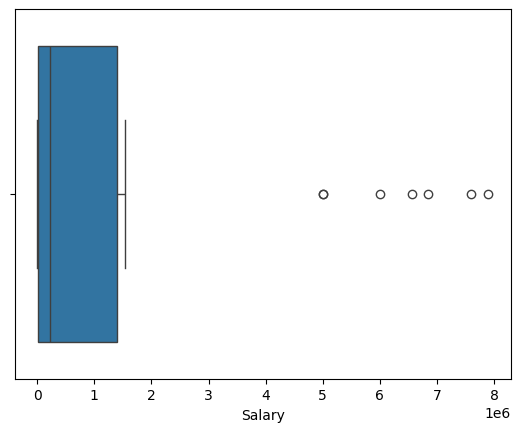

In [ ]:

sns.boxplot(x=emp_clean['Salary'])
plt.show()

In [ ]:
x = emp[['Experience_Years']]

y = np.log1p(emp['Salary'])

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 1)

In [ ]:
print("x_test.shape :", x_test.shape)
print("y_test.shape :", y_test.shape)
print("x_train.shape :", x_train.shape)
print("y_train.shape :", y_train.shape)

x_test.shape : (7, 1)
y_test.shape : (7,)
x_train.shape : (28, 1)
y_train.shape : (28,)


In [ ]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(x_test)
pred_salary = np.expm1(y_pred)

print("Prediction Value :", pred_salary)

Prediction Value : [  29353.45184972  264037.04005873   29353.45184972   29353.45184972
 3125416.87292008 3125416.87292008   66898.23814368]


In [ ]:
r2 = r2_score(y_test, y_pred)
print("R2 Score :", r2)

R2 Score : 0.577120056637962


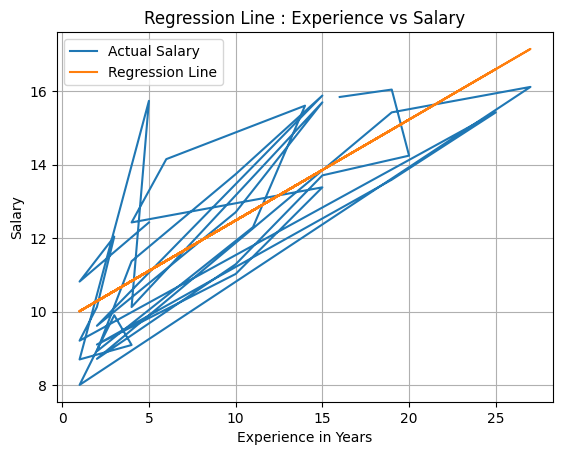

In [ ]:
plt.plot(x, y, label="Actual Salary")
plt.plot(x, model.predict(x), label = "Regression Line")

plt.xlabel("Experience in Years")
plt.ylabel("Salary")
plt.title("Regression Line : Experience vs Salary")
plt.legend()
plt.grid()
plt.show()

In [ ]:
emp[["Experience_Years", "Salary"]].mean()

,0
Experience_Years,9.200000e+00
Salary,2.059147e+06


In [ ]:
emp[["Experience_Years", "Salary"]].median()

,0
Experience_Years,6.0
Salary,250000.0


In [ ]:
emp[["Experience_Years", "Salary"]].corr()

,Experience_Years,Salary
Experience_Years,1.0000,0.6856
Salary,0.6856,1.0000


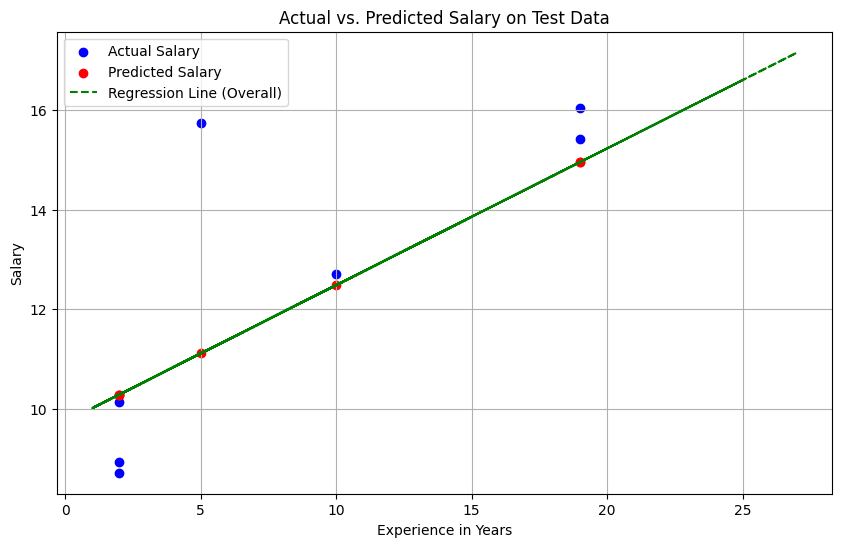

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(x_test, y_test, color='blue', label='Actual Salary')
plt.scatter(x_test, y_pred, color='red', label='Predicted Salary')
plt.plot(x, model.predict(x), color='green', linestyle='--', label='Regression Line (Overall)')
plt.xlabel('Experience in Years')
plt.ylabel('Salary')
plt.title('Actual vs. Predicted Salary on Test Data')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print(emp_clean['Salary'].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

0.01       3960.0
0.05       6060.0
0.25      20000.0
0.50     220100.0
0.75    1400000.0
0.95    7147000.0
0.99    7804000.0
Name: Salary, dtype: float64
